In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch
sys.path.append('../../')

In [3]:
from neural_control.dynamics import SequentialDualSourcingModel, fractional_decoupling, binary_decoupling
from neural_control.demand_generators import FileBasedDemandGenerator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy

torch.set_default_tensor_type(torch.cuda.FloatTensor)

In [4]:
service_type = 'high_service'

In [5]:
base_cofing = dict(h = 5, b = 495, cr = 0, ce = 20, lr = 2, le = 0)
service_configs = dict(high_service = dict(b=495), low_service = dict(b=95))

In [6]:
current_results = [
    dict(baselines='NNC', b=495, mean_cost=747117, median_cost=692118, method='current'),
    dict(baselines='CDI', b=495, mean_cost=773993, median_cost=770362, method='current'),
    dict(baselines='NNC', b=495, mean_cost=620968, median_cost=666600, method='future'),
    dict(baselines='CDI', b=495, mean_cost=722346, median_cost=716001, method='future'),    
    dict(baselines='NNC', b=95, mean_cost=583873, median_cost=563711, method='current'),
    dict(baselines='CDI', b=95, mean_cost=736018, median_cost=735265, method='current'),
    dict(baselines='NNC', b=95, mean_cost=564003, median_cost=541150, method='future'),
    dict(baselines='CDI', b=95, mean_cost=684495, median_cost=682958, method='future')
]
pd.DataFrame(current_results)

,baselines,b,mean_cost,median_cost,method
0,NNC,495,747117,692118,current
1,CDI,495,773993,770362,current
2,NNC,495,620968,666600,future
3,CDI,495,722346,716001,future
4,NNC,95,583873,563711,current
5,CDI,95,736018,735265,current
6,NNC,95,564003,541150,future
7,CDI,95,684495,682958,future


In [7]:
fbd = FileBasedDemandGenerator()

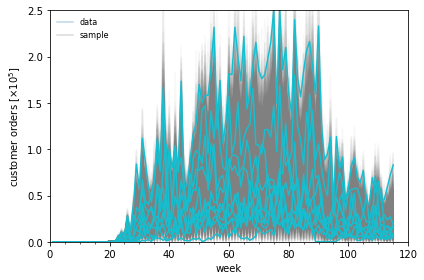

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    #fbd.plot_gaussian_process_vs_model()
    #fbd.plot_distributions()
    fbd.plot_samples_vs_data()


In [9]:
sourcing_parameters = dict(T=fbd.max_weeks)
sourcing_parameters.update(base_cofing)
sourcing_parameters.update(service_configs['high_service'])

In [10]:
N = 1 # aka minibatch size
T = fbd.max_weeks

sds = SequentialDualSourcingModel(**sourcing_parameters)
sds.I_0 = torch.tensor(0.0, requires_grad=True)


In [11]:
class SequentialController(torch.nn.Module):
    def __init__(self, lr, le):
        super().__init__()
        self.sequential_layer = torch.nn.LSTM(input_size=1, hidden_size=38, num_layers=1, batch_first=True)
        self.layer_norm = torch.nn.LayerNorm([T, 1])
        
        self.sequential_layer_2 = torch.nn.LSTM(input_size=1, hidden_size=38, num_layers=1, batch_first=True)
        self.layer_norm_2 = torch.nn.LayerNorm([T, 1])
        
        self.lr = lr
        self.le = le
        
        
    def calculate_qs(self, h):          
        qr_quant = fractional_decoupling(torch.relu(h[:, :, 0]+1)*torch.exp(h[:, :, 1:18].sum(-1)))
        qr_dec = binary_decoupling(h[:, :, 18])
        
        qe_quant = fractional_decoupling(torch.relu(h[:, :, 19]+1)*torch.exp(h[:, :, 20:37].sum(-1)))
        qe_dec = binary_decoupling(h[:, :, 37])
        
        return qr_quant*qr_dec, qe_quant*qe_dec
        
    def forward(self, state):
        x = self.layer_norm(state)
        h, (h_T, c_T) =  self.sequential_layer(x)
        
        
        qr, qe = self.calculate_qs(h)
        
        arrived_qr = qr.roll(self.lr, dims=(1,)).unsqueeze(-1)
        arrived_qr[:, :self.lr, :] = 0*arrived_qr[:, :self.lr, :]
        
        arrived_qe = qe.roll(self.le, dims=(1,)).unsqueeze(-1)
        arrived_qe[:, :self.le, :] = 0*arrived_qe[:, :self.le, :]
        
        new_x = self.layer_norm_2(state + arrived_qr.cumsum(1) + arrived_qe.cumsum(1))
        h, (h_T, c_T) =  self.sequential_layer_2(x)
        qr, qe = self.calculate_qs(h)
        return qr,qe

In [12]:
sc = SequentialController(sourcing_parameters['lr'], sourcing_parameters['le'])

In [13]:
best_model = [deepcopy(sc.state_dict())]
best_cost = [np.infty]

In [14]:
optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-2)
optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

In [15]:
N=2048
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

In [16]:
future_demands.shape

torch.Size([2048, 115])

In [17]:
sc.train()
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
demands = torch.cat([initial_demands, future_demands], dim=-1).float()
past_demands = demands[:, :-1]
compressed_input = (inital_inventories - past_demands).unsqueeze(-1)

for i in range(30000):
    optimizer.zero_grad()
    new_qr, new_qe = sc(compressed_input)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe
    
    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]
    
    
    
    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    mean_costs = costs.mean()
    J = mean_costs#((costs > costs.quantile(0.5, dim=1, keepdim=True))*costs).mean()#mean_costs #+ (1.5*costs.max(dim=0).values).mean()
    

    
    J.backward()
    optimizer.step()
    
    if mean_costs.item() < best_cost[0] and i > 10000:
        #TODO check and load based on test set
        best_cost[0] = mean_costs.item()
        best_model[0] = deepcopy(sc.state_dict())
    
    if i%3000 == 0 and i > 0:
        optimizer = torch.optim.RMSprop(sc.parameters(), lr=10**(-(2 + i/10000)))
        optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)
        future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
        inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
        demands = torch.cat([initial_demands, future_demands], dim=-1).float()
        past_demands = demands[:, :-1]
        compressed_input = (fractional_decoupling(inital_inventories)  - past_demands).unsqueeze(-1)
        print(costs.mean())

tensor(1580977.1250, grad_fn=<MeanBackward0>)
tensor(1453302.8750, grad_fn=<MeanBackward0>)
tensor(1303417.8750, grad_fn=<MeanBackward0>)
tensor(1402152.8750, grad_fn=<MeanBackward0>)
tensor(1674152.8750, grad_fn=<MeanBackward0>)


KeyboardInterrupt: 

In [18]:
best_cost

[1387886.125]

In [19]:
sc.load_state_dict(best_model[0])

<All keys matched successfully>

In [21]:
N=4096
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

with torch.no_grad():
    sc.eval()
    future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
    demands = torch.cat([initial_demands, future_demands], dim=-1).float()

    past_demands = demands[:, :-1]
    compressed_input = (inital_inventories - past_demands).unsqueeze(-1)
    new_qr, new_qe = sc(compressed_input)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe

    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]

    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    print('Mean: ' + str(costs.mean().item()))
    print('Median: ' + str(costs.median().item()))

Mean: 3810585.25
Median: 1147819.0


In [22]:
costs.mean()

tensor(3810585.2500)

In [23]:
(new_qe > 0).any()

tensor(True)

In [24]:
new_qr

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.0602e+04, 2.0986e+04,
         2.3316e+04],
        [1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.4321e+04, 4.4140e+03,
         1.8557e+04],
        [1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.4755e+04, 3.0012e+04,
         2.1209e+04],
        ...,
        [1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.6919e+04, 5.1830e+03,
         1.3786e+04],
        [1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.2330e+04, 1.6683e+04,
         2.2640e+04],
        [1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.2587e+04, 1.6393e+04,
         2.2932e+04]])

In [25]:
new_qe

tensor([[ 1.,  0., 15.,  ...,  0.,  0.,  0.],
        [ 1.,  0., 14.,  ...,  0.,  0.,  0.],
        [ 1.,  0., 12.,  ...,  0.,  0.,  0.],
        ...,
        [ 1.,  0., 13.,  ...,  0.,  0.,  0.],
        [ 1.,  0., 11.,  ...,  0.,  0.,  0.],
        [ 1.,  0., 12.,  ...,  0.,  0.,  0.]])

In [26]:
costs

tensor([[2.5000e+01, 5.0000e+00, 3.8500e+02,  ..., 2.2796e+06, 2.2148e+06,
         2.2275e+06],
        [2.5000e+01, 5.0000e+00, 3.6000e+02,  ..., 4.5647e+05, 3.0222e+05,
         3.6806e+05],
        [2.5000e+01, 5.0000e+00, 3.1000e+02,  ..., 1.6174e+06, 1.8092e+06,
         1.9090e+06],
        ...,
        [2.5000e+01, 5.0000e+00, 3.3500e+02,  ..., 2.2909e+06, 2.0605e+06,
         2.0742e+06],
        [2.5000e+01, 5.0000e+00, 2.8500e+02,  ..., 2.7786e+07, 3.2698e+07,
         2.3775e+07],
        [2.5000e+01, 5.0000e+00, 3.1000e+02,  ..., 9.6183e+05, 9.2881e+05,
         7.6740e+05]])

In [27]:
demands

tensor([[    0.0000,     0.0000,     0.0000,  ..., 19381.3203, 46020.8125,
         28063.5488],
        [    0.0000,     0.0000,     0.0000,  ..., 17999.7969, 38491.7617,
         11151.6875],
        [    0.0000,     0.0000,     0.0000,  ..., 36559.7148,  7574.8125,
         14798.1797],
        ...,
        [    0.0000,     0.0000,     0.0000,  ..., 31698.5566, 52699.8164,
         14184.3975],
        [    0.0000,     0.0000,     0.0000,  ..., 12661.3545, 34117.7539,
         14302.6230],
        [    0.0000,     0.0000,     0.0000,  ..., 10975.4961, 33962.1250,
         64869.3555]])

In [28]:
invs

tensor([[ 1.0000e+00,  1.0000e+00,  1.7000e+01,  ...,  4.5591e+05,
          4.4296e+05,  4.4550e+05],
        [ 1.0000e+00,  1.0000e+00,  1.6000e+01,  ...,  9.1293e+04,
          6.0444e+04,  7.3613e+04],
        [ 1.0000e+00,  1.0000e+00,  1.4000e+01,  ...,  3.2348e+05,
          3.6183e+05,  3.8179e+05],
        ...,
        [ 1.0000e+00,  1.0000e+00,  1.5000e+01,  ...,  4.5818e+05,
          4.1211e+05,  4.1484e+05],
        [ 1.0000e+00,  1.0000e+00,  1.3000e+01,  ..., -5.6134e+04,
         -6.6057e+04, -4.8030e+04],
        [ 1.0000e+00,  1.0000e+00,  1.4000e+01,  ...,  1.9237e+05,
          1.8576e+05,  1.5348e+05]])